# **Projeto 1 - Regressão Linear**

**Aluno:** Henrique Valle Chaves

## Objetivo
Aplicar um modelo de **Regressão Linear** ao conjunto de dados **Wine Quality** do repositório UCI Machine Learning Repository, com o objetivo de prever a variável **quality** a partir das características físico-químicas do vinho.


## 1. Importação das bibliotecas
Nesta etapa, importamos as bibliotecas que serão usadas para manipulação dos dados, visualização gráfica, divisão entre treino e teste, treinamento do modelo e avaliação dos resultados.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## 2. Carregamento do dataset
O dataset utilizado é o **Wine Quality - Red Wine**, disponível no repositório UCI. Ele contém variáveis físico-químicas dos vinhos e uma nota de qualidade atribuída a cada amostra.

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'
df = pd.read_csv(url, sep=';')

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 3. Exploração inicial dos dados
Agora vamos verificar a estrutura do conjunto de dados, os tipos de variáveis e algumas estatísticas descritivas.

In [3]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 4. Separação entre variáveis explicativas e variável alvo
A variável que queremos prever é **quality**. As demais colunas serão usadas como entrada do modelo.

In [4]:
X = df.drop('quality', axis=1)
y = df['quality']

print('Formato de X:', X.shape)
print('Formato de y:', y.shape)

Formato de X: (1599, 11)
Formato de y: (1599,)


## 5. Divisão dos dados em treino e teste
O conjunto será dividido em 80% para treinamento e 20% para teste. Isso permite avaliar o desempenho do modelo em dados que ele não viu durante o treinamento.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (1279, 11)
X_test: (320, 11)
y_train: (1279,)
y_test: (320,)


## 6. Treinamento do modelo de Regressão Linear
Nesta etapa, criamos e treinamos o modelo com os dados de treinamento.

In [6]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)

print('Modelo treinado com sucesso!')

Modelo treinado com sucesso!


## 7. Realização das previsões
Após o treinamento, usamos o modelo para prever os valores da qualidade no conjunto de teste.

In [7]:
y_pred = modelo.predict(X_test)

resultado = pd.DataFrame({
    'Valor Real': y_test.values,
    'Valor Previsto': y_pred
})

resultado.head(10)

,Valor Real,Valor Previsto
0,6,5.346664
1,5,5.056313
2,6,5.664470
3,5,5.464515
4,6,5.725185
5,5,5.279287
6,5,5.034217
7,5,5.126233
8,5,5.745343
9,6,5.686650


## 8. Avaliação do modelo
Vamos avaliar o modelo utilizando duas métricas:

- **MSE (Mean Squared Error):** mede o erro médio quadrático das previsões.
- **R² (Coeficiente de Determinação):** mede quanto da variação da variável alvo é explicada pelo modelo.

In [8]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'R² Score: {r2:.4f}')

Mean Squared Error (MSE): 0.3900
R² Score: 0.4032


## 9. Visualização gráfica dos resultados
O gráfico abaixo compara os valores reais com os valores previstos pelo modelo.

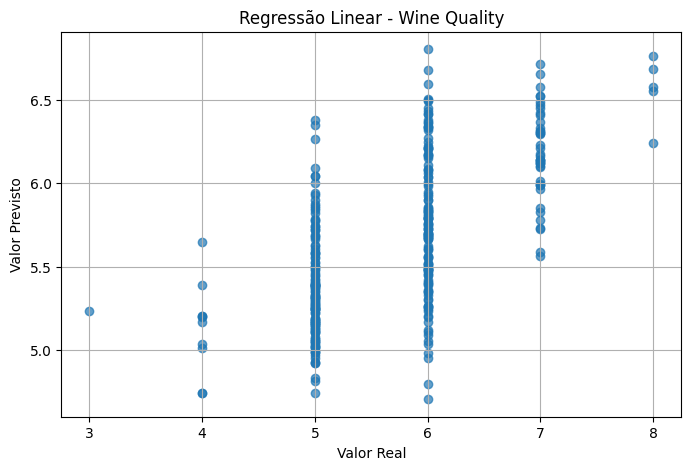

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Regressão Linear - Wine Quality')
plt.grid(True)
plt.show()

## 10. Coeficientes do modelo
Aqui observamos o peso de cada variável na predição da qualidade do vinho.

In [10]:
coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo.coef_
}).sort_values(by='Coeficiente', ascending=False)

coeficientes

,Variável,Coeficiente
9,sulphates,0.841172
10,alcohol,0.281890
0,fixed acidity,0.023085
3,residual sugar,0.006564
5,free sulfur dioxide,0.005627
6,total sulfur dioxide,-0.003644
2,citric acid,-0.140821
8,pH,-0.393688
1,volatile acidity,-1.001304
4,chlorides,-1.806503


## 11. Conclusão
Com base nos resultados obtidos, foi possível aplicar a técnica de **Regressão Linear** ao dataset **Wine Quality** para prever a variável de saída **quality**.

O modelo apresentou um determinado nível de desempenho medido pelas métricas **MSE** e **R²**, mostrando que a regressão linear consegue capturar parte da relação entre as variáveis físico-químicas e a qualidade do vinho.

Além disso, a análise dos coeficientes permite entender quais características exercem maior influência sobre a variável alvo. Dessa forma, a atividade demonstrou na prática o funcionamento de um modelo supervisionado de regressão.